**MLP**


---

Initial implementation by - **Vrutant Chaudhari**

Extended with additional evaluation metrices (ROC Curve, F1-Score, etc.) # New Section

In [36]:
#############################
#       IMPORT LIBRARIES    #
#############################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from IPython.display import display

In [37]:
NUM_TARGET_CLASSES = 3
RANDOM_STATE = 35
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 150
PATIENCE = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Using device:", DEVICE)

Using device: cpu


In [38]:
#############################
#  LOAD OR PREPARE DATASET  #
#############################

from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/ML Group Project CSCI 635/code')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
#############################
#  LOAD OR PREPARE DATASET  #
#############################

# Github
# X_train_path = "data/processed_data/X_train_scaled.csv"
# y_train_path = "data/processed_data/y_train.csv"
# X_test_path = "data/processed_data/X_test_scaled.csv"
# y_test_path = "data/processed_data/y_test.csv"

# Google Colab
X_train_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/X_train_scaled.csv"
y_train_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/y_train.csv"
X_test_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/X_test_scaled.csv"
y_test_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/y_test.csv"

X_train = pd.read_csv(X_train_path)
y_train = pd.read_csv(y_train_path).squeeze()

X_test = pd.read_csv(X_test_path)
y_test = pd.read_csv(y_test_path).squeeze()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

NUM_TARGET_CLASSES = len(np.unique(np.array(y_train).ravel()))
print("Number of target classes:", NUM_TARGET_CLASSES)


X_train: (1608, 11)
y_train: (1608,)
X_test: (392, 11)
y_test: (392,)
Number of target classes: 3


In [40]:
#############################
#   TRAIN / VAL PREPARATION #
#############################

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

X_train_tensor = torch.tensor(X_train_split.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train split:", X_train_split.shape)
print("Validation split:", X_val.shape)

Train split: (1286, 11)
Validation split: (322, 11)


In [41]:
#############################
#    DEFINE MLP MODELS      #
#############################

class PyTorchMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_classes=3, dropout_rate=0.0):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [42]:
#############################
#   TRAINING HELPER LOGIC   #
#############################

def regularization_penalty(model, l1_lambda=0.0):
    penalty = 0.0
    if l1_lambda > 0:
        penalty += l1_lambda * sum(param.abs().sum() for param in model.parameters())
    return penalty

def run_epoch(model, loader, criterion, optimizer=None, l1_lambda=0.0):
    training = optimizer is not None
    if training:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        if training:
            optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss = loss + regularization_penalty(model, l1_lambda)
            if training:
                loss.backward()
                optimizer.step()
        preds = torch.argmax(logits, dim=1)
        total_loss += loss.item() * X_batch.size(0)
        total_correct += (preds == y_batch).sum().item()
        total_samples += y_batch.size(0)
    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    return epoch_loss, epoch_acc


def train_model(
    model,
    train_loader,
    val_loader,
    learning_rate=0.001,
    num_epochs=100,
    l1_lambda=0.0,
    l2_lambda=0.0,
    early_stopping=False,
    patience=10
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=l2_lambda
    )
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
    best_val_loss = float("inf")
    best_state_dict = None
    wait = 0
    model.to(DEVICE)
    for epoch in range(num_epochs):
        train_loss, train_acc = run_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            l1_lambda=l1_lambda
        )
        val_loss, val_acc = run_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            optimizer=None,
            l1_lambda=l1_lambda
        )
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        if early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break
    if early_stopping and best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    return model, history

def predict_model(model, X_tensor):
    model.eval()
    model.to(DEVICE)
    with torch.no_grad():
        logits = model(X_tensor.to(DEVICE))
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()
        predictions = np.argmax(probabilities, axis=1)
    return predictions, probabilities

In [43]:
#############################
#      TRAIN MLP MODELS     #
#############################

input_dim = X_train.shape[1]

model_configs = {
    "Baseline MLP": {
        "dropout_rate": 0.0,
        "l1_lambda": 0.0,
        "l2_lambda": 0.0,
        "early_stopping": False
    },
    "Dropout MLP": {
        "dropout_rate": 0.3,
        "l1_lambda": 0.0,
        "l2_lambda": 0.0,
        "early_stopping": False
    },
    "L1 MLP": {
        "dropout_rate": 0.0,
        "l1_lambda": 1e-5,
        "l2_lambda": 0,
        "early_stopping": False
    },
    "L2 MLP": {
        "dropout_rate": 0.0,
        "l1_lambda": 0,
        "l2_lambda": 1e-4,
        "early_stopping": False
    },
    "L1 + L2 MLP": {
        "dropout_rate": 0.0,
        "l1_lambda": 1e-5,
        "l2_lambda": 1e-4,
        "early_stopping": False
    },
    "Full Regularized MLP": {
        "dropout_rate": 0.3,
        "l1_lambda": 1e-5,
        "l2_lambda": 1e-4,
        "early_stopping": True
    }
}

models = {}
histories = {}

for name, config in model_configs.items():
    print(f"\nTraining {name}...")
    model = PyTorchMLP(
        input_dim=input_dim,
        hidden_dim=32,
        num_classes=NUM_TARGET_CLASSES,
        dropout_rate=config["dropout_rate"]
    )

    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        learning_rate=LEARNING_RATE,
        num_epochs=NUM_EPOCHS,
        l1_lambda=config["l1_lambda"],
        l2_lambda=config["l2_lambda"],
        early_stopping=config["early_stopping"],
        patience=PATIENCE
    )

    models[name] = trained_model
    histories[name] = history

print("\nAll PyTorch MLP variants trained")


Training Baseline MLP...

Training Dropout MLP...

Training L1 MLP...

Training L2 MLP...

Training L1 + L2 MLP...

Training Full Regularized MLP...
Early stopping at epoch 130

All PyTorch MLP variants trained


In [44]:
#############################
#   MODEL SELECTION LOGIC   #
#############################

X_train_full_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
X_test_full_tensor = torch.tensor(np.array(X_test), dtype=torch.float32)

y_train_full = np.array(y_train).ravel()
y_test_full = np.array(y_test).ravel()

validation_results = []

for name, history in histories.items():
    validation_results.append([
        name,
        max(history["val_acc"]),
        min(history["val_loss"])
    ])

validation_df = pd.DataFrame(
    validation_results,
    columns=["Model", "Best Validation Accuracy", "Best Validation Loss"]
)

display(validation_df.sort_values(by="Best Validation Accuracy", ascending=False).reset_index(drop=True))

best_model_name = validation_df.sort_values(
    by=["Best Validation Accuracy", "Best Validation Loss"],
    ascending=[False, True]
).iloc[0]["Model"]

best_model = models[best_model_name]

print("Selected final model:", best_model_name)

,Model,Best Validation Accuracy,Best Validation Loss
0,Dropout MLP,0.972050,0.087044
1,L1 MLP,0.972050,0.078703
2,Full Regularized MLP,0.962733,0.102631
3,L2 MLP,0.962733,0.083760
4,Baseline MLP,0.959627,0.091770
5,L1 + L2 MLP,0.953416,0.090082


Selected final model: L1 MLP


In [45]:
#############################
#    TRAINING EVALUATION    #
#############################

y_train_pred, _ = predict_model(best_model, X_train_full_tensor)
train_accuracy = np.mean(y_train_pred == y_train_full)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9832089552238806


In [46]:
#############################
#        PREDICTION         #
#############################

y_pred, probabilities = predict_model(best_model, X_test_full_tensor)

print("Probabilities shape:", probabilities.shape)
print("Prediction shape:", y_pred.shape)

Probabilities shape: (392, 3)
Prediction shape: (392,)


In [47]:
#############################
#          ACCURACY         #
#############################

accuracy = np.mean(y_test_full == y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9923


In [48]:
#############################
#     PER CLASS ACCURACY    #
#############################

for i in range(NUM_TARGET_CLASSES):
    k = (y_test_full == i)
    acc = np.mean(y_pred[k] == i)
    print(f"Class {i} accuracy: {acc:.4f}")

Class 0 accuracy: 1.0000
Class 1 accuracy: 0.9925
Class 2 accuracy: 0.6667


In [49]:
#############################
#     CONFUSION MATRIX      #
#############################

cm = pd.crosstab(
    pd.Series(y_test_full, name="Actual"),
    pd.Series(y_pred, name="Predicted")
)
display(cm)

Predicted,0,1,2
Actual,,,
0,252,0,0
1,1,133,0
2,0,2,4


In [50]:
#############################
#  PRECISION / RECALL / F1  #
#############################

print(classification_report(y_test_full, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       252
           1       0.99      0.99      0.99       134
           2       1.00      0.67      0.80         6

    accuracy                           0.99       392
   macro avg       0.99      0.89      0.93       392
weighted avg       0.99      0.99      0.99       392



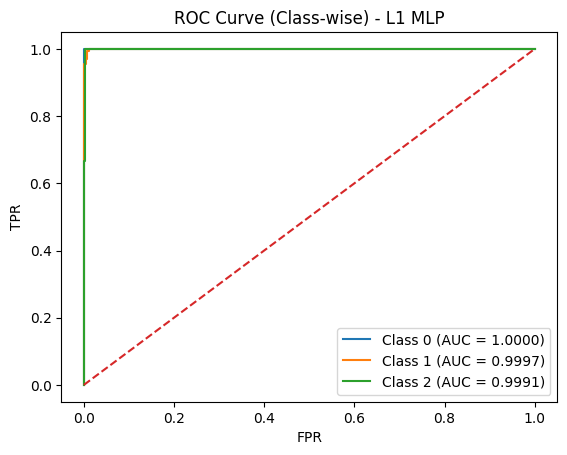

In [51]:
#############################
#  ROC CURVE (CLASS-WISE)   #
#############################

y_test_one_hot = label_binarize(y_test_full, classes=np.arange(NUM_TARGET_CLASSES))

for i in range(NUM_TARGET_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"ROC Curve (Class-wise) - {best_model_name}")
plt.legend()
plt.show()

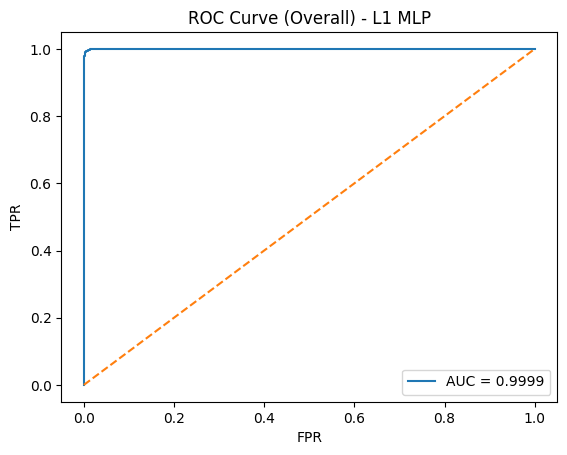

In [52]:
#############################
#    ROC CURVE (OVERALL)    #
#############################

fpr, tpr, _ = roc_curve(y_test_one_hot.ravel(), probabilities.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"ROC Curve (Overall) - {best_model_name}")
plt.legend()
plt.show()

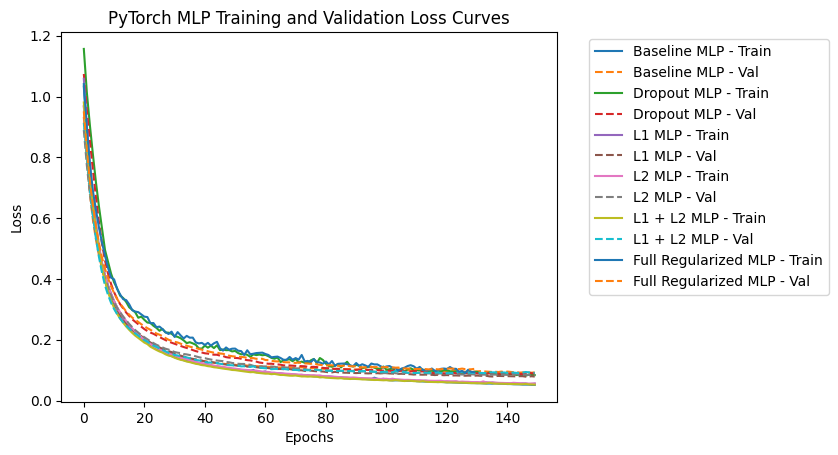

In [53]:
#############################
#        LOSS CURVES        #
#############################

for name, history in histories.items():
    plt.plot(history["train_loss"], label=f"{name} - Train")
    plt.plot(history["val_loss"], linestyle='--', label=f"{name} - Val")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("PyTorch MLP Training and Validation Loss Curves")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [54]:
#############################
#      COMPARISON TABLE     #
#############################

comparison_rows = []

for name, model in models.items():
    train_pred, _ = predict_model(model, X_train_full_tensor)
    test_pred, _ = predict_model(model, X_test_full_tensor)

    comparison_rows.append({
        "Model": name,
        "Train Accuracy": np.mean(train_pred == y_train_full),
        "Best Validation Accuracy": max(histories[name]["val_acc"]),
        "Test Accuracy": np.mean(test_pred == y_test_full),
        "Final Train Loss": histories[name]["train_loss"][-1],
        "Best Validation Loss": min(histories[name]["val_loss"])
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["Best Validation Accuracy", "Best Validation Loss"],
    ascending=[False, True]
).reset_index(drop=True)

display(comparison_df)

,Model,Train Accuracy,Best Validation Accuracy,Test Accuracy,Final Train Loss,Best Validation Loss
0,L1 MLP,0.983209,0.972050,0.992347,0.056195,0.078703
1,Dropout MLP,0.980721,0.972050,0.992347,0.083872,0.087044
2,L2 MLP,0.978856,0.962733,0.994898,0.055782,0.083760
3,Full Regularized MLP,0.976368,0.962733,0.989796,0.093492,0.102631
4,Baseline MLP,0.978856,0.959627,0.992347,0.051544,0.091770
5,L1 + L2 MLP,0.979478,0.953416,0.989796,0.052548,0.090082
